<a href="https://colab.research.google.com/github/oriol-pomarol/codegeo_workshops/blob/lstm_workshop/10_time_series_with_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9. Deep into Neural Networks - Time series with LSTMs

In previous workshops, we focused on teaching machine learning models to transform a set of input features into a target prediction. In those settings, each prediction was treated independently of each other as a mapping from an input vector (features) to an output (target). However, many real-world problems involve data that are inherently ordered. For example, observations may be collected over time. In such situations, the value at a given position is influenced by preceding values. Examples include **climatic time series**, in which present conditions depend on accumulated past dynamics, and language, in which the meaning of a word depends on the words that came before it.

When order matters, models must process data sequentially and retain relevant information from earlier positions. In some cases, **short-term dependencies** are sufficient, while in others, **long-term patterns** (such as seasonal effects) play a crucial role. Capturing dependencies across multiple time scales is therefore essential in many applications. **Recurrent neural networks (RNNs)** introduce the idea of memory by maintaining an internal hidden state that is updated at each step of a sequence. However, standard RNNs often struggle to learn long-term dependencies due to unstable gradient propagation during training.

In this workshop, we will explore **Long Short-Term Memory (LSTM) networks**, which provide a more stable and effective mechanism for preserving information across long sequences. The effect of LSTMs becomes clear when working with real sequential data, so in the following sections, we will compare different models for forecasting time series of Snow Water Equivalent (SWE).

## 9.1 Problem definition

In this notebook, we will use as our forecasting example the daily meteorological data and observed Snow Water Equivalent (SWE) from one station of the [ESM-Snowmip dataset](https://doi.org/10.1594/PANGAEA.897575) (supplement to [Menard et al., 2019](https://doi.org/10.5194/essd-11-865-2019)), in particular the one located at Reynolds Mountain East (U.S., state of Montana).

![picture](images/reynolds_mountain_snow.jpg)
*Photo: Troy Smith (Flickr). Licensed under CC BY-NC-ND 2.0.*

The meteorological data, which will be our input predictors, consists of the daily averaged values of the temperature (Tair), snowfall (Snowf), and short-wave radiation (SWdown), coming from in-situ measurements at a meteorological station located at the site.

SWE represents how much water you would get if you would melt the snowpack completely. In short, you can think of it as the "amount" of snow. Our goal will be to predict its daily value, measured at 12:00 LT with a snow pillow. Predicting time series of snow is a difficult task, since the snowmelt does not happen instantly; instead it needs a "ripening" period before starting to melt. This makes it the perfect target for LSTMs, which are especially designed to capture such temporal dependencies.


### Import and preprocess data

We start by loading the data of the Reynolds Mountain East station, which is stored as 'rme'. Then we split the data chronologically:
- First 15 years of data → used for training
- Last 5 years (after October 2003) → used for testing

Because this is a time-series problem, we must respect temporal order. The model should never use future information when learning to forecast.

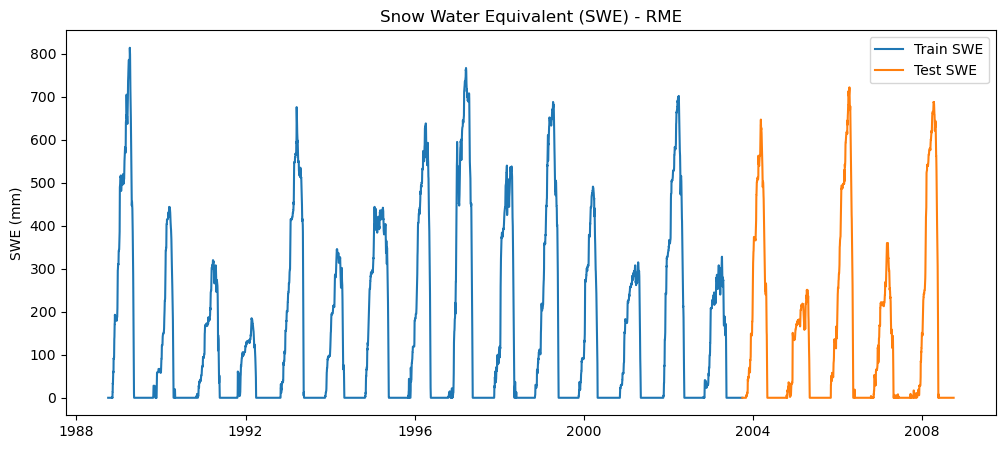

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Reproducibility for workshop
np.random.seed(42)
tf.random.set_seed(42)

# Load data
station_name = 'rme'
data_url = "https://raw.githubusercontent.com/oriol-pomarol/codegeo_workshops/lstm_workshop/datasets/snow_forecasting/"

filename = f"swe_met_insitu_{station_name}.csv"
rme_data = pd.read_csv(data_url + filename, parse_dates=[0], index_col=0)


# Train/test split
train_data = rme_data[rme_data.index < '2003-10-01'].copy()
test_data  = rme_data[rme_data.index >= '2003-10-01'].copy()

target_col = "obs_swe"
feature_cols = ["Snowf", "Tair", "SWdown"]

# Plot train/test SWE
plt.figure(figsize=(12, 5))
plt.plot(train_data[target_col], label="Train SWE")
plt.plot(test_data[target_col], label="Test SWE")
plt.title("Snow Water Equivalent (SWE) - RME")
plt.ylabel("SWE (mm)")
plt.legend()
plt.show()

Before training the models, we standardise the predictor variables. Neural networks (and so LSTMs) train more efficiently when inputs are on a similar scale, so we fit a `StandardScaler` on the training data, and then apply it to both training and testing sets. By using the training data only for scaling the variables, we avoid leaking information about the predictors' average and standard deviation from the future into the past.

In [59]:
# Scale predictors using training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[feature_cols]).astype(np.float32)
X_test  = scaler.transform(test_data[feature_cols]).astype(np.float32)

y_train = train_data[target_col].values.astype(np.float32)
y_test  = test_data[target_col].values.astype(np.float32)

n_features = X_train.shape[1]

## 9.2 A naive approach - FCNN

The first model we are going to try is a Fully Connected Neural Network (**FCNN**), meaning all neurons within consequent layers are connected with each other. If you don't know what that means, run back to our [Workshop on Neural Networks](https://github.com/oriol-pomarol/codegeo_workshops/blob/main/3_understanding_neural_networks.ipynb).

This model looks at the predictor variables from a single day (today) and produces a forecast for that same date. Each prediction is computed independently from the others. The model does not carry information forward in time, nor does it know anything about the past time steps. Therefore, it treats every day as a separate input–output pair. Let us take a look at how the training data looks like for this model.

In [60]:
print(f"The shape of the predictor training data is: {X_train.shape}")
print(f"The shape of the target training data is: {y_train.shape}")

print(f"\nFirst training sample:")
print(X_train[0], "->", y_train[0])

The shape of the predictor training data is: (5478, 3)
The shape of the target training data is: (5478,)

First training sample:
[-0.33303335  1.1369369   0.21844581] -> 0.0


Next, the model is trained with early stopping to prevent overfitting, and we compare their performance on the test period using RMSE. To learn more about overfitting, check our [Workshop about Over/underfitting](https://github.com/oriol-pomarol/codegeo_workshops/blob/main/6_over_under_fitting.ipynb). To evaluate it, we predict for the test set and compute the Root Mean Squared Error.

In [61]:
# Define early stopping callback to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Build a fully connected neural network (FCNN) as a baseline model
fcnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="relu")
])
fcnn_model.compile(optimizer="adam", loss="mse")

# Train the FCNN model
fcnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stop]
)

# Evaluate the FCNN model on the test set
fcnn_pred = fcnn_model.predict(X_test, verbose=0).flatten()
fcnn_rmse = np.sqrt(mean_squared_error(y_test, fcnn_pred))
print(f"Fully connected neural network - RMSE: {fcnn_rmse:.3f}")

Fully connected neural network - RMSE: 159.769


### Adding past information

In time series forecasting, it is often important to include not only the information from the time step in which we are predicting but also past values. The easiest way to do that is by adding the values of the predictor variables from previous time steps as additional inputs.

Let's train again an FCNN, but this time adding the lagged predictor values of up to 7 days before. First, we create a new dataset that includes the lagged predictors.

In [62]:
# Define how many past time steps to include as features for the lagged model
lagged_length = 7

# Create lagged features for training and testing
def create_lagged_features(X, y, n_lags):
    X_lagged, y_lagged = [], []
    for i in range(n_lags, len(X)):
        X_lagged.append(X[i-n_lags:i].flatten())
        y_lagged.append(y[i])
    return np.array(X_lagged), np.array(y_lagged)

X_train_lagged, y_train_lagged = create_lagged_features(X_train, y_train, lagged_length)
X_test_lagged, y_test_lagged = create_lagged_features(X_test, y_test, lagged_length)

print(f"The shape of the lagged predictor training data is: {X_train_lagged.shape}")
print(f"The shape of the lagged target training data is: {y_train_lagged.shape}")

print(f"\nFirst lagged training sample:")
print(X_train_lagged[0], "->", y_train_lagged[0])

The shape of the lagged predictor training data is: (5471, 21)
The shape of the lagged target training data is: (5471,)

First lagged training sample:
[-0.33303335  1.1369369   0.21844581 -0.33303335  1.2901491   0.15794875
 -0.33303335  1.3762711   0.13433002 -0.33303335  1.1326545   0.10946821
 -0.33303335  1.034637    0.04731366 -0.33303335  1.1026783   0.0410982
 -0.33303335  1.0103705   0.08253451] -> 0.0


As you can see, the shape is slighty different now. We lose a few samples (i.e., rows) at the beginning of our dataset since we don't have access to the previous predictor values, and we gain a lot more predictors (i.e., columns), specifically `lagged_predictors = n_predictors * lagged_length`. This is because for every variable we take the values in the past `lagged_length` days from the prediction. Let's update our FCNN model structure with the new input shape and train the new "lagged" model.

In [63]:
# Use the same architecture as the FCNN but with the added lagged features
lagged_model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features*lagged_length,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="relu")
])
lagged_model.compile(optimizer="adam", loss="mse")

# 
lagged_model.fit(
    X_train_lagged, y_train_lagged,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stop]
)

lagged_pred = lagged_model.predict(X_test_lagged, verbose=0).flatten()
lagged_rmse = np.sqrt(mean_squared_error(y_test_lagged, lagged_pred))
print(f"Lagged neural network - RMSE: {lagged_rmse:.3f}")

Lagged neural network - RMSE: 129.185


Let's see how the different predicted time series look like.

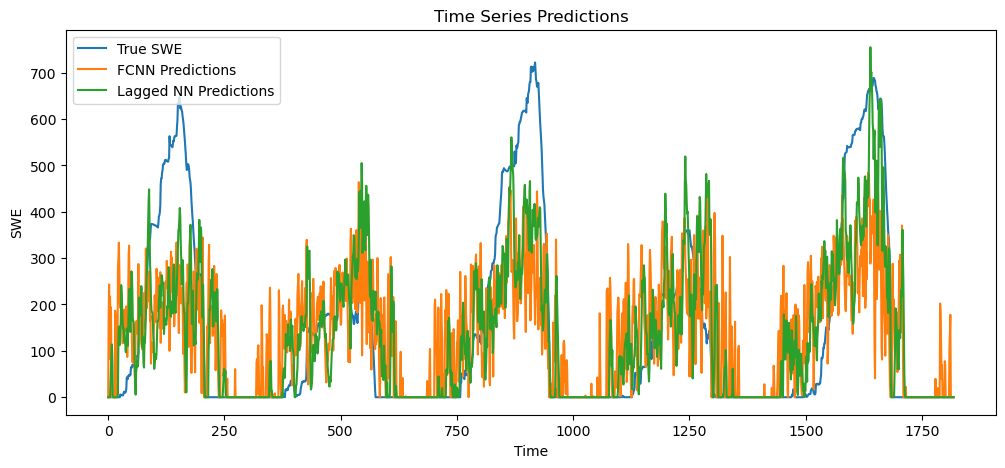

In [64]:
# Plot predictions vs true values for the test set
plt.figure(figsize=(12, 5))
plt.plot(y_test_lagged, label="True SWE")
plt.plot(fcnn_pred[-len(y_test_lagged):], label="FCNN Predictions")
plt.plot(lagged_pred, label="Lagged NN Predictions")
plt.xlabel("Time")
plt.ylabel("SWE")
plt.title("Time Series Predictions")
plt.legend()
plt.show()

We can already see a considerable improvement from the basic NN above. However, the main drawbacks of this approach are that we are making the model more complex by adding significantly more input variables, which are often highly correlated, and also that the order of the inputs is not know to the model.

## 9.3 Adding memory - the LSTM

Understanding Long Short-Term Memory (LSTM) models can be challenging, especially given their multiple internal components and the terminology used to describe their architecture. However, the underlying idea is conceptually simple: LSTMs regulate how information is stored, updated, and used over a sequence.
LSTMs maintain two internal states:

- A hidden state, which contributes directly to predictions (short-term memory).
- A cell state, which serves as a more persistent memory (long-term memory).

<img src="https://d2l.ai/_images/lstm-3.svg" style="width:1000px; background-color: white;">

**Source:** [Zhang et al.](https://d2l.ai/)

The evolution of the cell state is controlled by three mechanisms known as **gates**. These gates determine how information flows through the network at each step of the sequence:
- **Forget gate:** Determines how much of the previous cell state is retained, allowing irrelevant information to be discarded.
- **Input gate:** Determines how much of the current input is incorporated into the cell state.
- **Output gate:** Regulates how much of the cell state influences the hidden state and, consequently, the prediction.

Together, these gated mechanisms provide a controlled and stable way of modelling dependencies across long sequences.

Compared to FCNNs, the key difference of LSTMs is not just that it receives multiple days as input, but that it can deal with them sequentially, maintaining an internal state that evolves through time. This internal state acts like a memory of recent conditions, allowing the model to represent how the snowpack evolves from day to day rather than treating each day independently. In other words, the Dense model makes a prediction from a static snapshot, while the LSTM builds and updates a dynamic representation of the system before making its forecast.

### LSTMs in practice

While in theory you could run the model directly for the full time series, using it as a single "observation" for the model to train, it is common to split it in smaller chunks to prevent memory constrains and speed up training. The size of this chunks is given by a variable called `sequence_length`, which determines how many previous days are provided to the model at once. Let's start with 7, to mimick the lagged FCNN model.

Here we use the `timeseries_dataset_from_array` function from Keras, which automatically creates the training sequences and divides them in batches. Let us see how the inputs look for the first batch.

In [65]:
# Use past L days of predictors to predict SWE.
sequence_length = 7

# Create the training time series dataset
train_ds = tf.keras.preprocessing.timeseries_dataset_from_array(
    data=X_train,
    targets=y_train,
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=True
)

# Create the test time series dataset (no shuffling)
test_ds = tf.keras.preprocessing.timeseries_dataset_from_array(
    data=X_test,
    targets=y_test,
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False
)

# Show the shape of the first batch of training data
first_batch = next(iter(train_ds))
print(f"The shape of the lstm predictor training data (1st batch) is: {first_batch[0].shape}")
print(f"The shape of the lstm target training data (1st batch) is: {first_batch[1].shape}")

print(f"\nFirst LSTM training sample (predictors):")
print(first_batch[0][0].numpy(), "->", first_batch[1][0].numpy())

The shape of the lstm predictor training data (1st batch) is: (32, 7, 3)
The shape of the lstm target training data (1st batch) is: (32,)

First LSTM training sample (predictors):
[[-0.33303335 -0.15014079  0.5031136 ]
 [-0.33303335 -0.29811892  0.74551636]
 [-0.33303335  0.12583148  1.2812886 ]
 [-0.33303335  0.5074347   1.2187197 ]
 [-0.33303335  0.46508715  0.3270091 ]
 [ 0.00138457 -0.30906257 -0.0131835 ]
 [-0.06549902 -0.7820222   0.76043344]] -> 533.0


As you can see, ignoring the fact that we are only seing the 32 samples stored in this batch in the first dimension, the shape of the data is not that different from the previous case. It also consists of a single target, and the inputs corresponding to 7 time steps with 3 predictor variables each. However, they are not all being fed to the LSTM model directly and without structure, they are provided one step at a time, for the LSTM model iterate over them with its internal state. Let's see what we can get out of this model.

Creating the model in Keras is simple; instead of choosing only Dense layers in our `Sequential` model, we want to introduce at least one `LSTM` layer. The training and evaluation look exactly the same. 

In [69]:
# Build the LSTM model
lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length, n_features)),
    tf.keras.layers.LSTM(64,activation="relu"),
    tf.keras.layers.Dense(1,activation="relu")
])
lstm_model.compile(optimizer="adam", loss="mse")

# Train the LSTM model
lstm_model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    verbose=0,
    # callbacks=[early_stop]
)

# Evaluate the LSTM model on the test set
lstm_pred = lstm_model.predict(test_ds, verbose=0).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test[sequence_length-1:], lstm_pred))
print(f"LSTM (7-day window) RMSE: {lstm_rmse:.3f}")

LSTM (7-day window) RMSE: 127.244


We now compare the forecasts from both models against the observed SWE in the test period.

From the RMSE values computed earlier, we already know that the **LSTM** performs similarly. However, some improvements can be observed for some years visually in the plot below. The black line represents the observed SWE, while the coloured lines show the forecasts from each model.

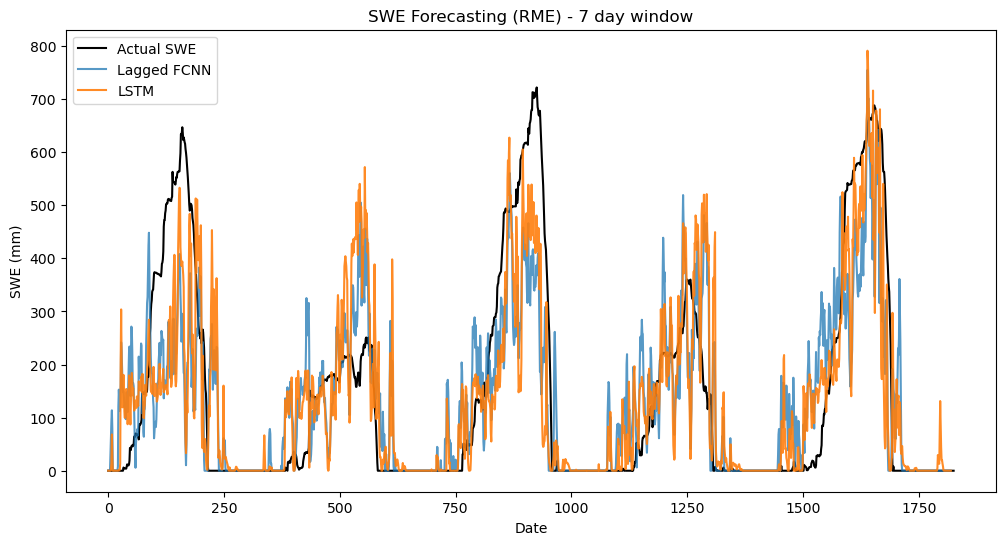

In [73]:
# Plot predictions vs true values for the test set
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual SWE", color="black")
plt.plot(lagged_pred, label="Lagged FCNN", alpha=0.75)
plt.plot(lstm_pred, label="LSTM", alpha=0.9)
plt.title("SWE Forecasting (RME) - 7 day window")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.legend()
plt.show()